In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
import plotly.express as px

In [2]:
df = pd.read_csv('physical_activity.csv')
df['Description'] = df['Description'].fillna('')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 672 entries, 0 to 671
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   672 non-null    int64  
 1   Actvitiy     672 non-null    object 
 2   Description  672 non-null    object 
 3   Cluster      672 non-null    int64  
 4   x            672 non-null    float64
 5   y            672 non-null    float64
 6   z            672 non-null    float64
 7   SVD_1        672 non-null    float64
 8   SVD_2        672 non-null    float64
dtypes: float64(5), int64(2), object(2)
memory usage: 47.4+ KB


In [4]:
tfidf = TfidfVectorizer(stop_words='english', max_features=1000)
X_tfidf = tfidf.fit_transform(df['Description'])

In [5]:
svd_model = TruncatedSVD(n_components=5, random_state=42)
X_svd_full = svd_model.fit_transform(X_tfidf)

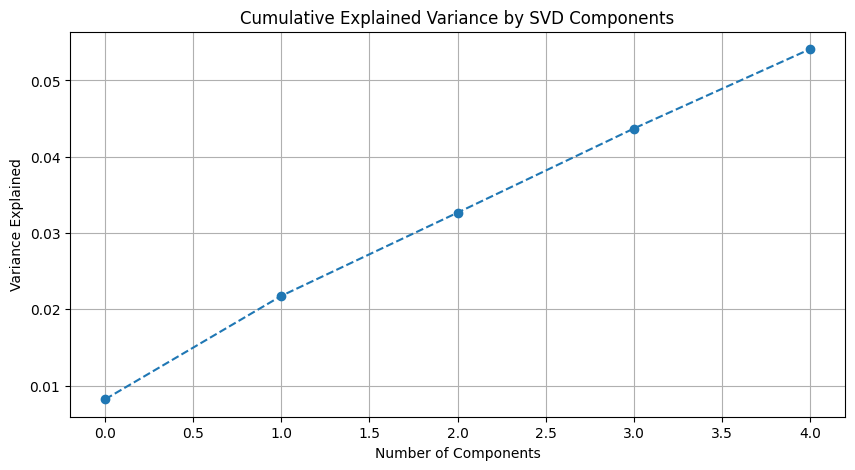

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(np.cumsum(svd_model.explained_variance_ratio_), marker='o', linestyle='--')
plt.title('Cumulative Explained Variance by SVD Components')
plt.xlabel('Number of Components')
plt.ylabel('Variance Explained')
plt.grid(True)
plt.show()

In [7]:
def remove_outliers_iqr(data, n_features=3):
    # Convert to DF for filtering
    cols = [f'SVD_{i+1}' for i in range(n_features)]
    temp_df = pd.DataFrame(data[:, :n_features], columns=cols)
    
    mask = pd.Series(True, index=temp_df.index)
    for col in cols:
        Q1 = temp_df[col].quantile(0.25)
        Q3 = temp_df[col].quantile(0.75)
        IQR = Q3 - Q1
        mask &= (temp_df[col] >= (Q1 - 1.5 * IQR)) & (temp_df[col] <= (Q3 + 1.5 * IQR))
    
    return mask

In [8]:
mask = remove_outliers_iqr(X_svd_full)
df_clean = df[mask].copy()
X_final = X_svd_full[mask][:, :10]

In [9]:
inertia = []
K_range = range(2, 21)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_final)
    inertia.append(km.inertia_)

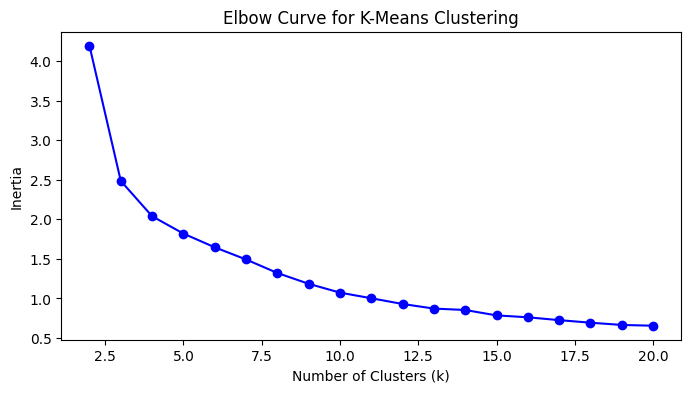

In [10]:
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker='o', color='blue')
plt.title('Elbow Curve for K-Means Clustering')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.show()

In [11]:
best_k = 6 # Adjust based on Elbow Plot results
model = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_clean['Cluster'] = model.fit_predict(X_final)

In [12]:
score = silhouette_score(X_final, df_clean['Cluster'])
print(f"Average Silhouette Score: {score:.4f}")

Average Silhouette Score: 0.4190


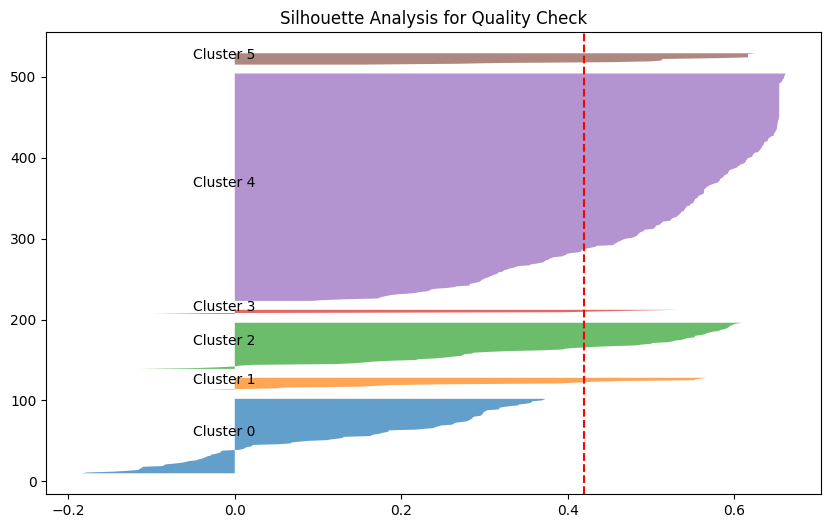

In [13]:
sample_values = silhouette_samples(X_final, df_clean['Cluster'])
plt.figure(figsize=(10, 6))
y_lower = 10
for i in range(best_k):
    cluster_v = sample_values[df_clean['Cluster'] == i]
    cluster_v.sort()
    y_upper = y_lower + len(cluster_v)
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_v, alpha=0.7)
    plt.text(-0.05, y_lower + 0.5 * len(cluster_v), f'Cluster {i}')
    y_lower = y_upper + 10
plt.axvline(x=score, color="red", linestyle="--")
plt.title("Silhouette Analysis for Quality Check")
plt.show()

In [14]:
df_clean['x'] = X_final[:, 0]
df_clean['y'] = X_final[:, 1]
df_clean['z'] = X_final[:, 2]

fig = px.scatter_3d(
    df_clean, 
    x='x', y='y', z='z',
    color='Cluster',
    hover_name='Actvitiy',
    hover_data=['Description'],
    title=f"Interactive 3D Clusters (k={best_k})",
    template='plotly_dark'
)
fig.show()

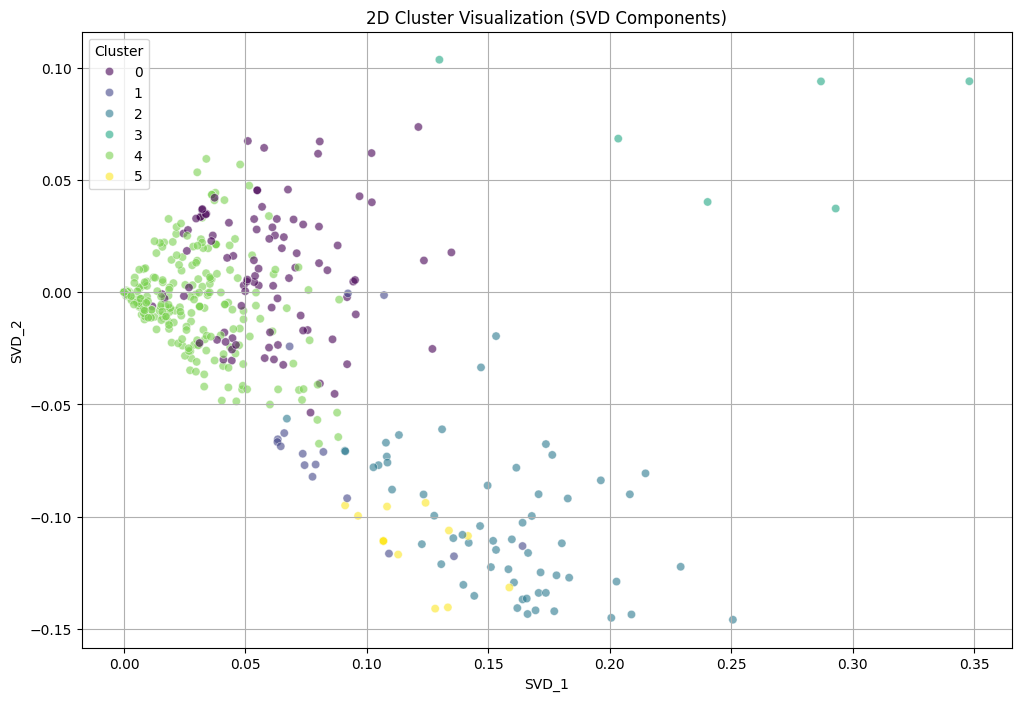

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure SVD components are added to the cleaned dataframe for plotting
# SVD_1 and SVD_2 correspond to the first two columns of X_final
df_clean['SVD_1'] = X_final[:, 0]
df_clean['SVD_2'] = X_final[:, 1]

# 2D Cluster Visualization
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_clean, 
    x='SVD_1', 
    y='SVD_2', 
    hue='Cluster', 
    palette='viridis', 
    alpha=0.6
)
plt.title('2D Cluster Visualization (SVD Components)')
plt.grid(True)
plt.show()

In [16]:
# Save results for the Meta-Model
df_clean.to_csv('physical_Activity.csv', index=False)
print("Physical Activity results exported to physical_Activity.csv")

Physical Activity results exported to physical_Activity.csv


In [18]:
import pickle
('physical_kmeans_model.pkl', 'wb')

('physical_kmeans_model.pkl', 'wb')